In [51]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
import plotly.express as px
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import seaborn as sns
from category_encoders import OneHotEncoder

In [52]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [53]:
df.dtypes

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [54]:
pd.DataFrame(df.isnull().sum()).T

,age,sex,bmi,children,smoker,region,charges
0,0,0,0,0,0,0,0


In [55]:
nums_col = df.select_dtypes("number").columns
for col in nums_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5*IQR

    lower_outliers = df[df[col]< lower_fence][col].values
    upper_outliers = df[df[col]> upper_fence][col].values
    print(f"Column: {col}")
    print(f"Lower Outliers: {len(lower_outliers)}")
    print(f"Upper Outliers: {len(upper_outliers)}")
    print("="*50)


Column: age
Lower Outliers: 0
Upper Outliers: 0
Column: bmi
Lower Outliers: 0
Upper Outliers: 9
Column: children
Lower Outliers: 0
Upper Outliers: 0
Column: charges
Lower Outliers: 0
Upper Outliers: 139


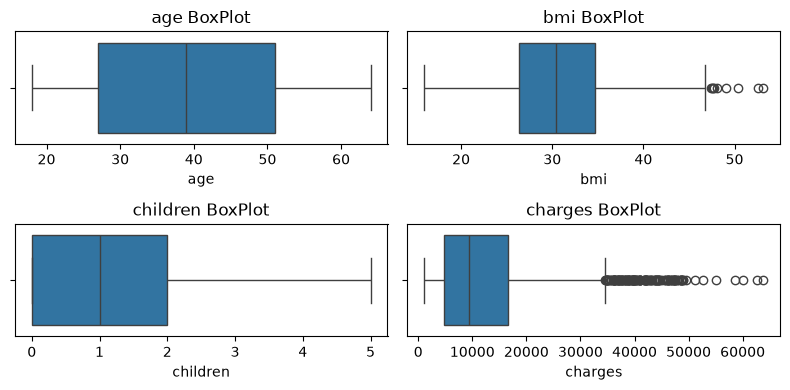

In [56]:
plt.figure(figsize=(8,4))
for i, col in enumerate(nums_col):
    plt.subplot(2,2,i+1)
    sns.boxplot(df[col], orient= "h")
    plt.title(f"{col} BoxPlot")
plt.tight_layout()
plt.show()

In [57]:
for col in nums_col:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_fence = Q1 - 1.5*IQR
    upper_fence = Q3 + 1.5*IQR
    
    lower_outliers = df[df[col]< lower_fence][col].values
    upper_outliers = df[df[col]> upper_fence][col].values
    df[col] = df[col].replace(upper_outliers, upper_fence)

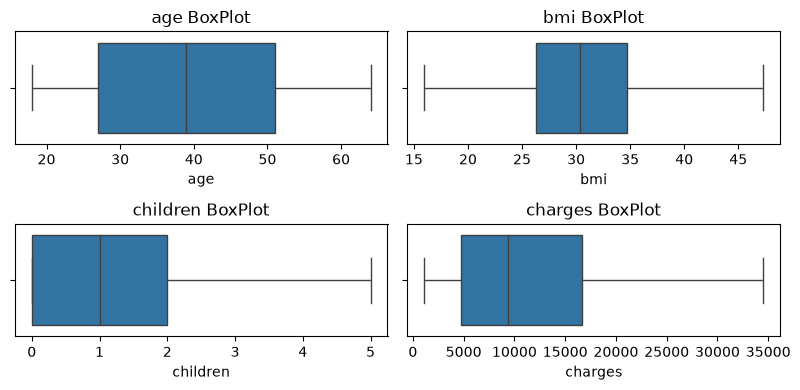

In [58]:
plt.figure(figsize=(8,4))
for i, col in enumerate(nums_col):
    plt.subplot(2,2,i+1)
    sns.boxplot(df[col], orient= "h")
    plt.title(f"{col} BoxPlot")
plt.tight_layout()
plt.show()

In [59]:
df.duplicated().sum()

np.int64(1)

In [60]:
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [61]:
x = df.drop("charges", axis=1)
y = df[["charges"]]

In [62]:
nums_col = x.select_dtypes("number").columns
scaler = MinMaxScaler()
x[nums_col] = scaler.fit_transform(x[nums_col])
x[nums_col]

,age,bmi,children
0,0.021739,0.381104,0.0
1,0.000000,0.568465,0.2
2,0.217391,0.543888,0.6
3,0.326087,0.215289,0.0
4,0.304348,0.412384,0.0
...,...,...,...
1333,0.695652,0.479094,0.6
1334,0.000000,0.509416,0.0
1335,0.000000,0.666773,0.0
1336,0.065217,0.314076,0.0


In [70]:
str_cols = x.select_dtypes("str").columns
encoder = OneHotEncoder(cols = str_cols, drop_invariant= True)
x = encoder.fit_transform(x)

In [74]:
x.head()

,age,sex_1,sex_2,bmi,children,smoker_1,smoker_2,region_1,region_2,region_3,region_4
0,0.021739,1,0,0.381104,0.0,1,0,1,0,0,0
1,0.000000,0,1,0.568465,0.2,0,1,0,1,0,0
2,0.217391,0,1,0.543888,0.6,0,1,0,1,0,0
3,0.326087,0,1,0.215289,0.0,0,1,0,0,1,0
4,0.304348,0,1,0.412384,0.0,0,1,0,0,1,0


In [73]:
y_scaler = MinMaxScaler()
y = y_scaler.fit_transform(y)
pd.DataFrame(y, columns=["charges"])

,charges
0,0.472408
1,0.018092
2,0.099725
3,0.625237
4,0.082265
...,...
1332,0.284069
1333,0.032490
1334,0.015223
1335,0.026555
